In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

########################################################################
# The output of torchvision datasets are PILImage images of range [0, 1].
# We transform them to Tensors of normalized range [-1, 1].

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 43.9MB/s]


In [ ]:
########################################################################
# 2. Define a Convolution Neural Network
# ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
# Copy the neural network from the Neural Networks section before and modify it to
# take 3-channel images (instead of 1-channel images as it was defined).

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 110)
        self.fc2 = nn.Linear(110, 74)
        self.fc3 = nn.Linear(74, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()



########################################################################
# 4. Train the network
# ^^^^^^^^^^^^^^^^^^^^
#
# This is when things start to get interesting.
# We simply have to loop over our data iterator, and feed the inputs to the
# network and optimize.

epochLoss = {1 : [],
             4 : [],
             1000 : []}
trainAccur = {1 : [],
             4 : [],
             1000 : []}
testAccur = {1 : [],
             4 : [],
             1000 : []}

numEpoch = 20

batch_size = [1, 4, 10] #I accidentally put batch sizes of 1, 4, and 10 causing an error

import torch.optim as optim

for BS in batch_size:
    net = Net()

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

    trainloader = torch.utils.data.DataLoader(trainset, batch_size=BS,
                                          shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=BS,
                                         shuffle=False, num_workers=2)


    for epoch in range(numEpoch):  # loop over the dataset multiple times
        epoch_loss = 0
        counter = 0
        running_loss = 0.0

        for i, data in enumerate(trainloader, 0):
            # get the inputs
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            epoch_loss += loss.item()
            counter += 1
        print('[%d] loss: %.3f' % (epoch + 1, epoch_loss / counter ))
        epochLoss[BS].append(epoch_loss / counter)
        epoch_loss = 0
        counter = 0

      # Finding the training accuracy of the model after the epoch

        correct = 0
        total = 0
        with torch.no_grad():
            for data in trainloader:
                images, labels = data
                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        trainAccur[BS].append(100 * correct / total)

        # Finding the test accuracy of the model after the epoch

        correct = 0
        total = 0
        with torch.no_grad():
            for data in testloader:
                images, labels = data
                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        testAccur[BS].append(100 * correct / total)


    print('Finished Training')

[1] loss: 1.682
[2] loss: 1.496
[3] loss: 1.453
[4] loss: 1.437
[5] loss: 1.435
[6] loss: 1.449
[7] loss: 1.449
[8] loss: 1.464
[9] loss: 1.464
[10] loss: 1.464
[11] loss: 1.505
[12] loss: 1.516
[13] loss: 1.517
[14] loss: 1.545
[15] loss: 1.588
[16] loss: 1.581
[17] loss: 1.619
[18] loss: 1.637
[19] loss: 1.666
[20] loss: 1.692
Finished Training
[1] loss: 1.728
[2] loss: 1.363
[3] loss: 1.236
[4] loss: 1.154
[5] loss: 1.095
[6] loss: 1.045
[7] loss: 1.002
[8] loss: 0.966
[9] loss: 0.931
[10] loss: 0.905
[11] loss: 0.883
[12] loss: 0.861
[13] loss: 0.842
[14] loss: 0.826
[15] loss: 0.805
[16] loss: 0.789
[17] loss: 0.781
[18] loss: 0.762
[19] loss: 0.759
[20] loss: 0.739
Finished Training
[1] loss: 1.929


KeyError: 10

In [ ]:
########################################################################
# Trainging again but this time only with the 1000 batch size

import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 110)
        self.fc2 = nn.Linear(110, 74)
        self.fc3 = nn.Linear(74, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()



########################################################################
# 4. Train the network
# ^^^^^^^^^^^^^^^^^^^^
#
# This is when things start to get interesting.
# We simply have to loop over our data iterator, and feed the inputs to the
# network and optimize.

epochLoss = {1 : [],
             4 : [],
             1000 : []}
trainAccur = {1 : [],
             4 : [],
             1000 : []}
testAccur = {1 : [],
             4 : [],
             1000 : []}

numEpoch = 20

import torch.optim as optim

net = Net()

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=1000,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000,
                                         shuffle=False, num_workers=2)


for epoch in range(numEpoch):  # loop over the dataset multiple times
    epoch_loss = 0
    counter = 0
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        epoch_loss += loss.item()
        counter += 1
    print('[%d] loss: %.3f' % (epoch + 1, epoch_loss / counter ))
    epochLoss[1000].append(epoch_loss / counter)
    epoch_loss = 0
    counter = 0

  # Finding the training accuracy of the model after the epoch

    correct = 0
    total = 0
    with torch.no_grad():
        for data in trainloader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    trainAccur[1000].append(100 * correct / total)

    # Finding the test accuracy of the model after the epoch

    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    testAccur[1000].append(100 * correct / total)


print('Finished Training')

[1] loss: 2.303
[2] loss: 2.303
[3] loss: 2.302
[4] loss: 2.301
[5] loss: 2.300
[6] loss: 2.299
[7] loss: 2.298
[8] loss: 2.296
[9] loss: 2.294
[10] loss: 2.292
[11] loss: 2.289
[12] loss: 2.284
[13] loss: 2.279
[14] loss: 2.273
[15] loss: 2.266
[16] loss: 2.257
[17] loss: 2.247
[18] loss: 2.236
[19] loss: 2.223
[20] loss: 2.208
Finished Training


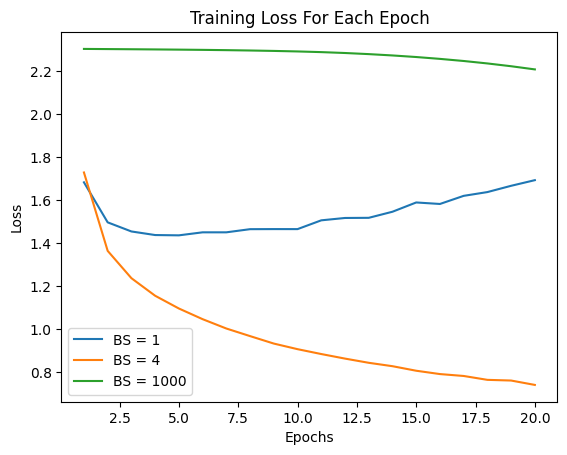

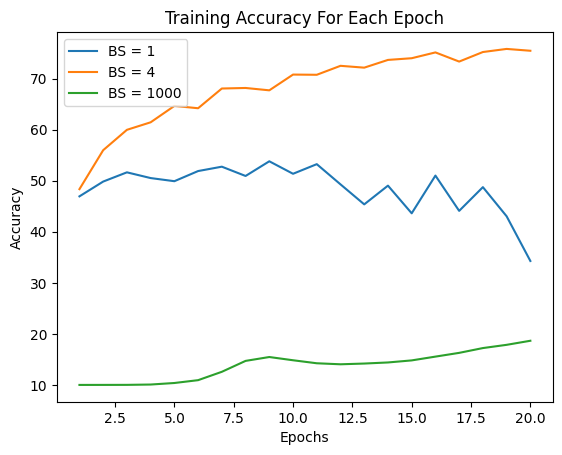

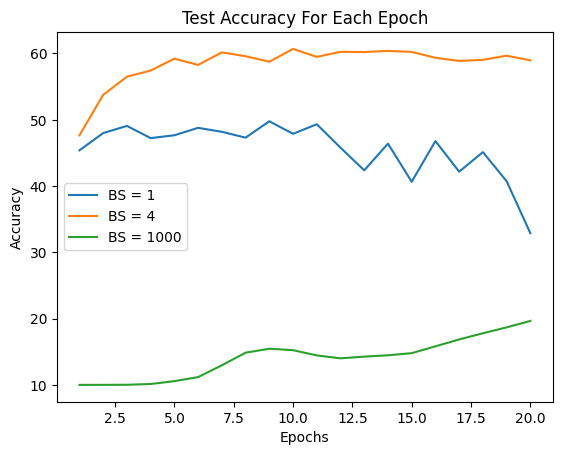

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1,numEpoch+1)

#I have to re-enter the values to get a combined graph because of the coding error

epochLoss[1] = [1.6822881153772251, 1.4958497963067543, 1.4534441328277279, 1.4367779425850549, 1.4353877199484277, 1.4494284374996187, 1.4494363974687958, 1.4641058033538805,
                1.464496560598939, 1.4643797179090001, 1.5052949574593202, 1.5162693792004254, 1.516964966742717, 1.5452891366263228, 1.588474085881483, 1.5814729697332894,
                1.6192715869200347, 1.6368610873466625, 1.6660852074979164, 1.692357574064915]
epochLoss[4] = [1.7281290236616134, 1.3630485437601805, 1.2358745098859072, 1.1540907304301857, 1.0947228642609717, 1.0450298843377828, 1.0015015341852604, 0.9661291974971816,
                0.9314068180463091, 0.9053247144050803, 0.8826494637244754, 0.8614262524165726, 0.8418810717432015, 0.8260447496269411, 0.8049154191058409, 0.7893778431948367,
                0.7805176020348223, 0.7624627092517283, 0.7592576698514633, 0.7388467058502801]
trainAccur[1] = [46.936, 49.832, 51.64, 50.518, 49.904, 51.892, 52.748, 50.928, 53.804, 51.358, 53.242, 49.284, 45.366, 49.034, 43.616, 51.004, 44.092, 48.74, 43.032, 34.276]
trainAccur[4] = [48.346, 55.978, 59.968, 61.442, 64.65, 64.198, 68.062, 68.168, 67.706, 70.792, 70.752, 72.508, 72.148, 73.664, 73.996, 75.134, 73.34, 75.21, 75.818, 75.458]
testAccur[1] = [45.4, 48.0, 49.08, 47.24, 47.67, 48.79, 48.19, 47.31, 49.78, 47.89, 49.33, 45.8, 42.38, 46.41, 40.66, 46.79, 42.18, 45.13, 40.74, 32.9]
testAccur[4] = [47.65, 53.76, 56.5, 57.43, 59.22, 58.28, 60.17, 59.59, 58.76, 60.69, 59.49, 60.25, 60.22, 60.39, 60.24, 59.35, 58.89, 59.04, 59.67, 58.96]

plt.plot(x,epochLoss[1], label= "BS = 1")
plt.plot(x,epochLoss[4], label= "BS = 4")
plt.plot(x,epochLoss[1000], label= "BS = 1000")
plt.title("Training Loss For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(x,trainAccur[1], label= "BS = 1")
plt.plot(x,trainAccur[4], label= "BS = 4")
plt.plot(x,trainAccur[1000], label= "BS = 1000")
plt.title("Training Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(x,testAccur[1], label= "BS = 1")
plt.plot(x,testAccur[4], label= "BS = 4")
plt.plot(x,testAccur[1000], label= "BS = 1000")
plt.title("Test Accuracy For Each Epoch")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()